# Quasi-Monte Carlo Generators, Randomizers, and Fast Transforms

Original QMCPy demo: [`QMCPy/demos/talk_paper_demos/ACMTOMS_Sorokin_2025/acm_toms_sorokin_2025.ipynb`](../../../../QMCPy/demos/talk_paper_demos/ACMTOMS_Sorokin_2025/acm_toms_sorokin_2025.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/talk_paper_demos/ACMTOMS_Sorokin_2025/acm_toms_sorokin_2025.ipynb)

Julia companion to the ACM TOMS 2025 article. This notebook covers the same three themes: **point-set generation**, **fast kernel transforms** (FFTBR/IFFTBR and FWHT), and **adaptive integration**. The generation-time benchmarks from the Python notebook are covered by `make bench-all`; see `benchmark/`.


## Setup

In [1]:
using QMC
using Printf
using Statistics
using Random

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots


## Snippets

### Point Sets

The three main QMC point-set families — lattice rules, digital nets, and Halton sequences — each support a range of randomization strategies. In QMC.jl the generators are constructed once and reused; `gen_samples(dd, n)` returns an $n \times d$ matrix in $[0,1)^d$.


In [2]:
d = 52
n = 2^10

lattice = Lattice(d;
    randomize  = true,          # random shift
    seed       = nothing,       # fresh seed each time; pass integer for reproducibility
)
x_lat = gen_samples(lattice, n)
@printf("Lattice   shape = (%d, %d),  mean = %.4f\n", size(x_lat)..., mean(x_lat))


Lattice   shape = (1024, 52),  mean = 0.5000


In [3]:
dnb2 = DigitalNetB2(d;
    randomize = "LMS_DS",      # Matousek LMS + digital shift
    seed      = nothing,
)
x_dn = gen_samples(dnb2, n)
@printf("DigitalNet shape = (%d, %d), mean = %.4f\n", size(x_dn)..., mean(x_dn))


DigitalNet shape = (1024, 52), mean = 0.5000


In [4]:
halton = Halton(d;
    randomize = true,           # random digital shift
    seed      = nothing,
)
x_hal = gen_samples(halton, n)
@printf("Halton    shape = (%d, %d),  mean = %.4f\n", size(x_hal)..., mean(x_hal))


Halton    shape = (1024, 52),  mean = 0.5000


### Kernel Methods

#### Lattice + FFTBR / IFFTBR

For lattice rules, the shift-invariant kernel Gram matrix is diagonalized by the **Bernoulli (bracket) FFT**. `bro_fft` and `bro_ifft` implement these transforms. `compute_kernel_eigenvalues` returns the eigenvalue vector $\lambda = \sqrt{n}\,\text{FFTBR}(k_1)$ where $k_1$ is the first column of the Gram matrix.


In [5]:
d_k = 3
m_k = 10
n_k = 2^m_k

lat_k = Lattice(d_k; seed=7)
x_k   = gen_samples(lat_k, n_k)

λ  = compute_kernel_eigenvalues(KernelShiftInvar(order=2), x_k)
@printf("Kernel eigenvalue summary: min = %.3e, max = %.3f\n", minimum(λ), maximum(λ))

# Round-trip check: bro_ifft ∘ bro_fft = identity
y  = randn(n_k)
y_rt = bro_ifft(bro_fft(y))
@printf("FFTBR/IFFTBR round-trip max error = %.3e\n", maximum(abs.(y .- y_rt)))

# Solve verification: K*(K⁻¹y) ≈ y
yt = bro_fft(y)
v  = bro_ifft(yt ./ λ)                   # K⁻¹ y
Kv = bro_ifft(bro_fft(v) .* λ)           # K * (K⁻¹ y)
@printf("K*(K⁻¹y) max relative error = %.3e\n",
        maximum(abs.(Kv .- y) ./ (abs.(y) .+ 1e-15)))


Kernel eigenvalue summary: min = -4.009e+00, max = 1024.000
FFTBR/IFFTBR round-trip max error = 8.882e-16


K*(K⁻¹y) max relative error = 1.470e-09


#### Digital Net + FWHT

For digital nets, the Walsh-Hadamard transform plays the same role. `fwht` is its own inverse up to a factor of $n$: applying it twice gives back the original signal divided by $n$.


In [6]:
μ  = compute_kernel_eigenvalues(KernelDigShiftInvar(order=2), gen_samples(DigitalNetB2(d_k; seed=7), n_k))

signal = randn(n_k)
coeffs = fwht(signal)
recovered = fwht(coeffs) ./ n_k
@printf("FWHT round-trip max error = %.3e\n", maximum(abs.(signal .- recovered)))
@printf("Digital-net kernel eigenvalue summary: min = %.3e, max = %.3f\n",
        minimum(μ), maximum(μ))


FWHT round-trip max error = 8.882e-16
Digital-net kernel eigenvalue summary: min = -1.421e-14, max = 924.975


### Integration

The **corner-peak** Genz integrand in $d=50$ dimensions:

$$f(\mathbf{x}) = \left(1 + \sum_{j=1}^{d} c_j x_j\right)^{-(d+1)}, \qquad c_j = \frac{0.25/j^2}{\sum_{k=1}^{d} 1/k^2}.$$

`CubQMCNetGRep` draws $R$ independent randomizations of a digital net, estimates the integral from each, and forms a Student-$t$ confidence interval across the $R$ estimates. This matches QMCPy's `CubQMCRepStudentT`.


In [7]:
function corner_peak(x)
    d = size(x, 2)
    c = (0.25 ./ (1:d).^2) ./ sum(1.0 ./ (1:d).^2)
    return (1.0 .+ x * c) .^ (-(d + 1))
end

R  = 10
d_cp = 50
dd_cp = DigitalNetB2(d_cp; seed=7, randomize="LMS_DS", graycode=false)
tm_cp = QMC.Uniform(dd_cp)
f_cp  = CustomFun(tm_cp, corner_peak)

sc_cp = CubQMCNetGRep(f_cp; abs_tol=1e-4, n_init=2^10, n_reps=R)
result_cp = integrate(sc_cp)
@printf("Corner-peak integral ≈ %.6f\n", result_cp.solution)
println(result_cp)


Corner-peak integral ≈ 0.014964
QMCResult(solution=1.496377e-02

, n_total=40960, error_bound=8.45e-05)


## Point Sets

Scatter plots of $n=2^{10}$ points from four representative generators in $d=2$ dimensions. The Python notebook shows 12 variants; this Julia version shows four canonical choices.


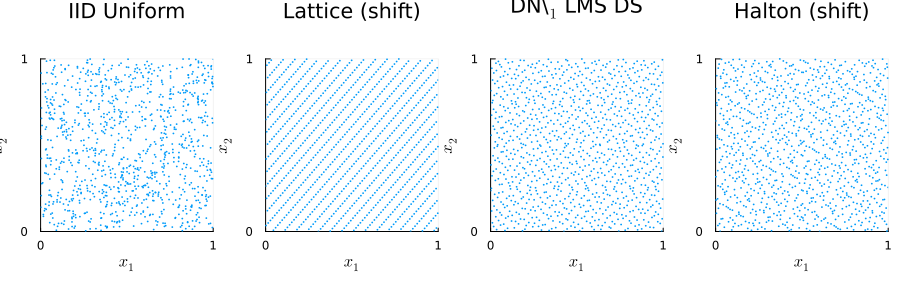

In [8]:
n_pts = 2^10
pt_data = [
    ("IID Uniform",          IIDStdUniform(2; seed=11)),
    ("Lattice (shift)",      Lattice(2; seed=11)),
    (raw"DN\$_1\$ LMS DS",  DigitalNetB2(2; randomize="LMS_DS", seed=11, t=63)),
    ("Halton (shift)",       Halton(2; randomize=true,     seed=11)),
]

if HAVE_PLOTS
    plots_list = []
    for (name, dd) in pt_data
        local x = gen_samples(dd, n_pts)
        local p = scatter(x[:, 1], x[:, 2];
            title=name, xlabel="\$x_1\$", ylabel="\$x_2\$",
            xlims=(0,1), ylims=(0,1), aspect_ratio=:equal,
            xticks=[0,1], yticks=[0,1],
            markersize=1, markerstrokewidth=0, label=nothing, size=(250, 280))
        push!(plots_list, p)
    end
    display(plot(plots_list...; layout=(1, 4), size=(900, 300)))
else
    for (name, dd) in pt_data
        local x = gen_samples(dd, n_pts)
        @printf("  %-28s  mean=(%.4f, %.4f)\n", name, mean(x[:,1]), mean(x[:,2]))
    end
end


## Convergence

We compare four point-set generators on three test functions of increasing complexity. For each combination we sweep $m = 8, 10, 12, 14, 16$ (i.e., $n = 2^m$) and record the RMSE across $R = 16$ independent randomizations. **This is a lightweight subset of the Python study** (which uses $m \leq 20$ and more test functions); for full benchmarks see `benchmark/`.


In [9]:
# Test functions (operating on (n, d) matrices, returning length-n vectors)

# f1: simple 1D,  ∫₀¹ (x eˣ - 1) dx = 0
simple_1d(x) = x[:, 1] .* exp.(x[:, 1]) .- 1.0

# f2: 2D product
simple_2d(x) = x[:, 2] .* exp.(x[:, 1] .* x[:, 2]) ./ (exp(1) - 2) .- 1.0

# f3: G-function in d=3
function G_func(x)
    d = size(x, 2)
    a = (1:d .- 2) ./ 2
    return vec(prod((abs.(4 .* x .- 2) .+ a') ./ (1 .+ a'), dims=2))
end

exact_vals = Dict(
    "f₁: xeˣ−1 (d=1)"      => exp(1) - 2,
    "f₂: x₂exp(x₁x₂)/(e−2)−1 (d=2)" => 0.0,
    "G-function (d=3)"      => 1.0,
)

function run_convergence(dd_fn, f_fn, d, m_vec, R)
    rmses = Float64[]
    for m in m_vec
        n = 2^m
        muhats = Float64[]
        for _ in 1:R
            dd = dd_fn(d)
            x  = gen_samples(dd, n)
            push!(muhats, mean(f_fn(x)))
        end
        push!(rmses, std(muhats))
    end
    return rmses
end

m_vec = [8, 10, 12, 14, 16]
R_cv  = 16
results_cv = Dict{String, Dict{String, Vector{Float64}}}()

test_fns = [
    ("f₁: xeˣ−1 (d=1)", simple_1d, 1),
    ("f₂: x₂exp(x₁x₂)/(e−2)−1 (d=2)", simple_2d, 2),
    ("G-function (d=3)", G_func, 3),
]
generators = [
    ("IID",     d -> IIDStdUniform(d)),
    ("Lattice", d -> Lattice(d)),
    ("DN LMS DS", d -> DigitalNetB2(d; randomize="LMS_DS")),
    ("Halton",  d -> Halton(d; randomize=true)),
]

for (fname, fn, d) in test_fns
    results_cv[fname] = Dict{String, Vector{Float64}}()
    for (gname, gfn) in generators
        results_cv[fname][gname] = run_convergence(gfn, fn, d, m_vec, R_cv)
    end
end

# Print a summary table
for (fname, fn, d) in test_fns
    println("\n", fname)
    println("  n" * join([@sprintf("%10d", 2^m) for m in m_vec]))
    for (gname, _) in generators
        rmses = results_cv[fname][gname]
        print(@sprintf("  %-10s", gname))
        for r in rmses
            print(@sprintf("  %8.2e", r))
        end
        println()
    end
end



f₁: xeˣ−1 (d=1)


  n       256      1024      4096     16384     65536
  IID         5.43e-02  2.58e-02  1.85e-02  6.44e-03  3.64e-03
  Lattice     2.55e-03  7.90e-04  2.50e-04  4.54e-05  1.03e-05
  DN LMS DS   2.63e-03  7.29e-04  1.68e-04  4.84e-05  1.55e-05
  Halton      2.99e-03  7.40e-04  2.13e-04  4.73e-05  1.29e-05

f₂: x₂exp(x₁x₂)/(e−2)−1 (d=2)
  n       256      1024      4096     16384     65536
  IID         5.06e-02  2.33e-02  1.15e-02  5.25e-03  2.40e-03
  Lattice     4.75e-03  1.13e-03  4.32e-04  9.55e-05  2.92e-05
  DN LMS DS   3.60e-03  7.79e-04  1.87e-04  4.58e-05  9.61e-06
  Halton      4.68e-03  2.11e-03  4.41e-04  9.24e-05  2.72e-05

G-function (d=3)
  n       256      1024      4096     16384     65536
  IID         3.85e-02  2.57e-02  1.24e-02  5.98e-03  2.77e-03
  Lattice     1.55e-03  8.31e-06  8.22e-07  2.06e-07  4.67e-09
  DN LMS DS   3.01e-02  7.05e-03  5.77e-05  2.78e-02  0.00e+00
  Halton      5.06e-03  1.31e-03  4.09e-04  6.75e-05  2.26e-05


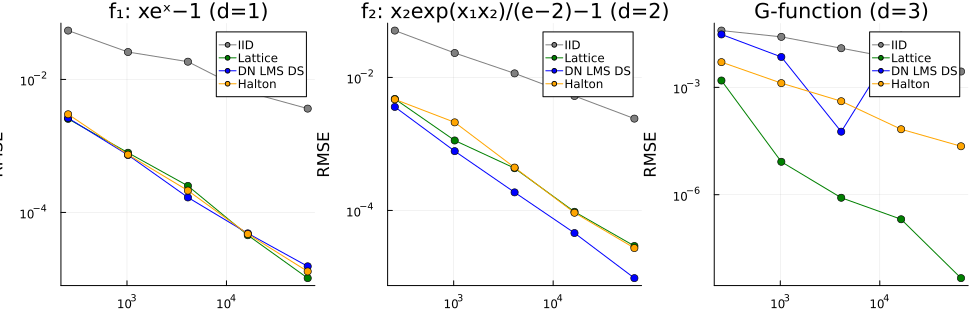

In [10]:
if HAVE_PLOTS
    colors_cv = [:gray, :green, :blue, :orange]
    ps = []
    for (fname, fn, d) in test_fns
        local p = plot(; title=fname, xlabel="\$n\$", ylabel="RMSE",
                   xscale=:log10, yscale=:log10, size=(350, 300), legend=:topright)
        for ((gname, _), col) in zip(generators, colors_cv)
            rmses = results_cv[fname][gname]
            rmses_plot = replace(rmses, 0.0 => NaN)
            plot!(p, 2 .^ m_vec, rmses_plot; label=gname, color=col, marker=:circle, markersize=4)
        end
        push!(ps, p)
    end
    display(plot(ps...; layout=(1, 3), size=(980, 320)))
end